# Knight Moves 6

<div align="center">
<img src="october-2024.png", width="30%">
<div>

I recall the rules of this puzzle below.

Pick distinct positive integers A, B, and C, and place them in the grid above. Your goal is to create two corner-to-corner trips — one from a1 to f6, and the other from a6 to f1 — both of which score exactly 2024 points.

A “trip” consists of knight’s moves. Squares may not be revisited within a trip.

The “score” for a trip is calculated as follows:

- Start with A points.
- Every time you make a move:
    - if your move is between two different integers, multiply your score by the value you are moving to;
    - otherwise, increment your score by the value you are moving to.
Can you find positive integers A, B, and C, as well as a pair of trips, that satisfy the criteria above? How low can you get A + B + C?

Please format your entry by concatenating your values for A, B, and C, followed by your a1-to-f6 tour, followed by your a6-to-f1 tour. For example, “1,2,253,a1,b3,c5,d3,f4,d5,f6,a6,c5,a4,b2,c4,d2,f1” would be a properly formatted entry.

To qualify for the leaderboard your value for A + B + C must be less than 50.

## Motivation

Above, we can see the board on which our knight is going to roam. This kind of problem makes me think about search algorithms and especially `dfs` or `bfs`. We are going to implement a search algorithm that is going to look for feasible paths while keeping in mind we need to minimize the objective function A + B + C.

## Brute Force Search

Since the board looks small, one might think that brute forcing the puzzle might be easy. However, the number of self-avoiding paths of knights move from one point to another on the board is very very big. 

For N=4, we get 138 which is quite small, but it grows exponentially and very fast. 

For N=5, we are already at 88920 which is big but manageable

For N=6, we are at so much the code doesn't finish. I know it's a code I made on the fly but still.

So brute force is for sure not the way to go. Or at least brute brute force is not the way, but intelligent brute forcing may be the right way to proceed.

Note that this was only the search for fixed A, B and C. We need to explore different values of A, B and C to get an answer to our puzzle.

To be in the leaderboard, we need to have A + B + C <= 50 so let's only count the triplets that sum to less than 50. Since ordering counts, we multiply this number by 3!=6 and get 17832.

At face value, this number is quite small, doing 17832 operations is not much. But doing 17832 operations that each take an hour is very long.

In [8]:
def count_knight_paths(n):
    if n == 1:
        return 1

    total = n * n
    target = total - 1
    offsets = [(1, 2), (2, 1), (2, -1), (1, -2),
               (-1, -2), (-2, -1), (-2, 1), (-1, 2)]

    # Precompute knight moves for each square
    moves = [[] for _ in range(total)]
    for r in range(n):
        for c in range(n):
            idx = r * n + c
            for dr, dc in offsets:
                nr, nc = r + dr, c + dc
                if 0 <= nr < n and 0 <= nc < n:
                    moves[idx].append(nr * n + nc)

    def dfs(pos, visited):
        if pos == target:
            return 1
        count = 0
        for nxt in moves[pos]:
            bit = 1 << nxt
            if not visited & bit:
                count += dfs(nxt, visited | bit)
        return count

    return dfs(0, 1)


if __name__ == "__main__":
    n = 4
    print(f"N = {n}: {count_knight_paths(n)} self-avoiding knight paths")

N = 4: 138 self-avoiding knight paths


## Pruning

An important aspect of these types of puzzles is pruning. Since we just saw it was impossible to explore all the possibilities, we need to get rid of the most paths. The sooner the better since every state likely spans from 1 to 8 more paths.

### Pruning with the score

Since we are only adding and multipying positive integers, the score can only go up. We can therefore stop the search if the score reaches a score that is greater than 2024. It will prune the paths that change zones very often since multiplying numbers with each other result in high numbers very quickly.

### Pruning with the knights moves directly

We can see that if we start from the top left, in order to even be able to reach the bottom right, we need to be ablee to make a knight move to the goal square. Meaning if the two possible moves are already visited, we can stop exploring this path. This condition probably appears later in the search.

Combining both also gives us an idea. For the path from the top left to the bottom right, if C square before the goal is already visited and C is not a divisor of 2024, we can stop exploring since the only way to get to the goal is through the B square which would imply multiplying the result by C.

#### Giving it a first go

These are the first ideas that come to my mind, we will see if it achieves anything good. 

Since we are probably going to end up with an enourmous amount of paths, likely we won't solve the puzzle with ony these methods, we are going to limit the max moves and see how many path it generated that are feasible for now. It will also be a way to see if we need more pruning methods or a different logic.

With the fact that the maximum number of moves for a single path is 35, if we have billions of paths with `MAX_MOVES=10`, we'll know we need to think of other methods

In [1]:
from itertools import combinations

def find_solutions(a, b, c, max_depth):
    solutions = []
    grid = {
        (0, 0): a, (0, 1): b, (0, 2): b, (0, 3): c, (0, 4): c, (0, 5): c,
        (1, 0): a, (1, 1): b, (1, 2): b, (1, 3): c, (1, 4): c, (1, 5): c,
        (2, 0): a, (2, 1): a, (2, 2): b, (2, 3): b, (2, 4): c, (2, 5): c,
        (3, 0): a, (3, 1): a, (3, 2): b, (3, 3): b, (3, 4): c, (3, 5): c,
        (4, 0): a, (4, 1): a, (4, 2): a, (4, 3): b, (4, 4): b, (4, 5): c,
        (5, 0): a, (5, 1): a, (5, 2): a, (5, 3): b, (5, 4): b, (5, 5): c
    }
    def get_next_states(coord, score):
        possible_moves = []
        current_square = grid[coord]
        r, c = coord
        for (dr, dc) in [(-2,-1), (-2,1), (-1,2), (1,2), (2,1), (2,-1), (1,-2), (-1,-2)]:
            if 0 <= r + dr <= 5 and 0 <= c + dc <= 5:
                new_coord = (r + dr, c + dc)
                new_square = grid[new_coord]
                if new_square != current_square:
                    possible_moves.append((new_coord, score * new_square))
                else:
                    possible_moves.append((new_coord, score + new_square))
        return possible_moves


    def dfs(start_pos, current_score, current_coord, n, path, solutions, max_depth):

        # Valid solutions or stop early
        if start_pos == (0, 0) and current_coord == (5, 5):
            if current_score == 2024:
                solutions.append(path.copy())
                return
        if start_pos == (5, 0) and current_coord == (0, 5):
            if current_score == 2024:
                solutions.append(path.copy())
                return
        if n > max_depth:
            solutions.append(path.copy())
            return
        
        # Pruning
        if current_score > 2024:
            return
        if start_pos == (0, 0):
            if (3, 4) in path and (4, 3) in path:
                return
            if (3, 4) in path and 2024 % grid[(5, 5)] != 0:
                return
        if start_pos == (5, 0):
            if (1, 3) in path and (2, 4) in path:
                return

        for next_coord, next_score in get_next_states(current_coord, current_score):
            if next_coord in path:
                continue
            path.append((next_coord, next_score))
            dfs(start_pos, next_score, next_coord, n + 1, path, solutions, max_depth)
            path.pop()

    dfs((0, 0), a, (0, 0), 1, [((0, 0), a)], solutions, max_depth)
    dfs((5, 0), a, (5, 0), 1, [((5, 0), a)], solutions, max_depth)
    return solutions


In [8]:
solutions = find_solutions(13, 25, 4, 13)

In [9]:
print(len(solutions))

753008


In [12]:
for path in solutions:
    if path[-1][1] == 2024:
        print(path)

## Observations

In order to test our function, I chose some random triplet that add up to less than 50 with c that divides 2024 to increase our chance to have a feasible path.
At 13 moves, we are already at amost 1M different paths with none that give us a feasible answer. We need a different approach.


## Working with numbers beforehand

Before diving into the knight paths, we could take a look at how to obtain 2024 based on a triplet (a,b,c) using only the operations `+` and `*`. With this or these sequences of operations, we can see if our path corresponds to such sequence of operations. If it follows an unknown sequenc of operations, we will know that the path can be safely killed off.

### Pruning still works here !

The idea is to have the least amount of possible paths leading us to 2024, that way, a very few paths will be possible and the more paths we will be able to cut off in the knights paths search. Thus we need to prune even our "operations" paths. For example, because of the grid's composition and the fact that the paths are self-avoiding, we cannot do A-C-A or C-A-C. Obviously, we cannot exceed 12 As, Bs or Cs either.
This allows us to reduce the number of ways to build 2024 using A, B, C and `+`, `*` operations

In [2]:
from collections import Counter

def get_operation_paths(A, B, C):
    possible_paths = []
    def dfs(path, x, current_square):
        if x == 2024:
            possible_paths.append(path.copy())
            return
        if x > 2024:
            return
        last_three = path[-3:] if len(path) >= 3 else path
        if last_three == [A, C, A] or last_three == [C, A, C]:
            return
        count = Counter(path)
        for _, cnt in count.items():
            if cnt > 12:
                return
        for next_square in [A, B, C]:
            if next_square == current_square:
                dfs(path + [next_square], x + next_square, next_square)
            else:
                dfs(path + [next_square], x * next_square, next_square)
    dfs([A], A, A)

    return possible_paths

In [3]:
possible_paths = get_operation_paths(13, 25, 4)
print(f"Number of possible paths: {len(possible_paths)}")

Number of possible paths: 1


## Combining both

I ran the script for a random triplet and got only one outcome. I surely got lucky but for this triplet, we went from testing all the possible paths leading to 2024 or not to testing the self avoiding knight paths of a unique combination of operations. Moreover, we can even more optimize the code by observing that we have to go to either A or B when coming from the top left, or even by witnessing that we can only start with a move that goes to A when starting from the bottom left.

This allows us to prune the paths wherever we are in the path, wheter we are at the beginning or near the end.

In [662]:
from collections import defaultdict

def get_operation_paths_v2(A, B, C):
    possible_paths = defaultdict(list)
    next_moves = [A, B, C]
    def dfs(path, x, current_square, start, counts):
        for count in counts.values():
            if count > 12:
                return
        if x == 2024:
            if start == "Top":
                if path[-2] == A or path[-1] != C:
                    return
            else:
                if path[-2] != C or path[-1] != C:
                    return
            possible_paths[start].append(path.copy())
            return

        if x > 2024:
            return

        last_three = path[-3:] if len(path) >= 3 else path
        if last_three == [A, C, A] or last_three == [C, A, C]:
            return

        if len(path) >= 2:
            if start == "Top":
                if path[1] == C:
                    return
            else:
                if path[1] != A:
                    return
        
        for next_square in next_moves:
            path.append(next_square)
            counts[next_square] += 1
            if next_square == current_square:
                dfs(path, x + next_square, next_square, start, counts)
            else:
                dfs(path, x * next_square, next_square, start, counts)
            path.pop()
            counts[next_square] -= 1
    counts = {A:1, B:0, C:0}
    dfs([A], A, A, "Top", counts)
    dfs([A], A, A, "Bottom", counts)

    return possible_paths

In [663]:
class SolutionFound(Exception):
    pass

def find_solutions_v2(a, b, c, max_depth, possible_paths):
    solutions = []
    grid = {
        (0, 0): a, (0, 1): b, (0, 2): b, (0, 3): c, (0, 4): c, (0, 5): c,
        (1, 0): a, (1, 1): b, (1, 2): b, (1, 3): c, (1, 4): c, (1, 5): c,
        (2, 0): a, (2, 1): a, (2, 2): b, (2, 3): b, (2, 4): c, (2, 5): c,
        (3, 0): a, (3, 1): a, (3, 2): b, (3, 3): b, (3, 4): c, (3, 5): c,
        (4, 0): a, (4, 1): a, (4, 2): a, (4, 3): b, (4, 4): b, (4, 5): c,
        (5, 0): a, (5, 1): a, (5, 2): a, (5, 3): b, (5, 4): b, (5, 5): c
    }
    def get_next_states(coord, score):
        possible_moves = []
        current_square = grid[coord]
        r, c = coord
        for (dr, dc) in [(-2,-1), (-2,1), (-1,2), (1,2), (2,1), (2,-1), (1,-2), (-1,-2)]:
            if 0 <= r + dr <= 5 and 0 <= c + dc <= 5:
                new_coord = (r + dr, c + dc)
                new_square = grid[new_coord]
                if new_square != current_square:
                    possible_moves.append((new_coord, score * new_square))
                else:
                    possible_moves.append((new_coord, score + new_square))
        return possible_moves


    def dfs(start_pos, current_score, current_coord, n, path, max_depth, possible_paths, visited):

        if start_pos == (0, 0) and current_coord == (5, 5):
            if current_score == 2024:
                solutions.append(path.copy())
                raise SolutionFound
        if start_pos == (5, 0) and current_coord == (0, 5):
            if current_score == 2024:
                solutions.append(path.copy())
                raise SolutionFound
        if n > max_depth:
            return
        
        # Pruning
        
        if current_score > 2024:
            return
        if start_pos == (0, 0):
            new_possible_paths = []
            if (3, 4) in path and (4, 3) in path:
                return
            if (3, 4) in path and 2024 % grid[(5, 5)] != 0:
                return

        if start_pos == (5, 0):
            if (1, 3) in path and (2, 4) in path:
                return

        new_possible_paths = []
        for possible_path in possible_paths:
            if possible_path[n-1] == grid[current_coord]:
                new_possible_paths.append(possible_path)
        if new_possible_paths == []:
            return

        for next_coord, next_score in get_next_states(current_coord, current_score):
            if next_coord in visited:
                continue
            path.append((next_coord, next_score))
            visited.add(next_coord)
            dfs(start_pos, next_score, next_coord, n + 1, path, max_depth, new_possible_paths, visited)
            path.pop()
            visited.discard(next_coord)
    if "Top" not in possible_paths or "Bottom" not in possible_paths:
            return []
    try:
        dfs((0, 0), a, (0, 0), 1, [((0, 0), a)], max_depth, possible_paths["Top"], set({(0,0)}))
    except SolutionFound:
        pass

    try:
        dfs((5, 0), a, (5, 0), 1, [((5, 0), a)], max_depth, possible_paths["Bottom"], set({(5,0)}))
    except SolutionFound:
        pass

    return solutions


## Let's put it to the test !

Below I will try to test the new functions I created that are supposedly way better than the function I had before.

Indeed, with the pruning in the operation paths, we will get few feasible paths and thus less feasible knight paths.

In order to test the functions I will try to gradually reduce the overall sum by taking arbitrary values of a, b and c and taking a random permutation of [a,b,c]

In [630]:
from itertools import permutations
import random

a, b, c = random.choice(list(permutations([2, 3, 4], 3)))
print(a, b, c)
possible_paths = get_operation_paths_v2(a, b, c)
print(len(possible_paths["Top"]), len(possible_paths["Bottom"]))
print()
solutions = find_solutions_v2(a, b, c, 36, possible_paths)
if solutions:
    print(a, b, c)
    print(solutions)

2 3 4
2763 1409

2 3 4
[[((0, 0), 2), ((1, 2), 6), ((3, 3), 9), ((5, 4), 12), ((4, 2), 24), ((2, 1), 26), ((0, 2), 78), ((2, 3), 81), ((3, 1), 162), ((5, 2), 164), ((4, 0), 166), ((3, 2), 498), ((1, 1), 501), ((0, 3), 2004), ((2, 4), 2008), ((0, 5), 2012), ((1, 3), 2016), ((3, 4), 2020), ((5, 5), 2024)], [((5, 0), 2), ((3, 1), 4), ((1, 0), 6), ((0, 2), 18), ((2, 3), 21), ((3, 5), 84), ((5, 4), 252), ((4, 2), 504), ((3, 4), 2016), ((1, 3), 2020), ((0, 5), 2024)]]


In [689]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

zone_grid = {
    (0,0):'A', (0,1):'B', (0,2):'B', (0,3):'C', (0,4):'C', (0,5):'C',
    (1,0):'A', (1,1):'B', (1,2):'B', (1,3):'C', (1,4):'C', (1,5):'C',
    (2,0):'A', (2,1):'A', (2,2):'B', (2,3):'B', (2,4):'C', (2,5):'C',
    (3,0):'A', (3,1):'A', (3,2):'B', (3,3):'B', (3,4):'C', (3,5):'C',
    (4,0):'A', (4,1):'A', (4,2):'A', (4,3):'B', (4,4):'B', (4,5):'C',
    (5,0):'A', (5,1):'A', (5,2):'A', (5,3):'B', (5,4):'B', (5,5):'C',
}
zone_colors = {'A': '#a6cee3', 'B': '#b2df8a', 'C': '#fdbf6f'}

def plot_path(ax, path, value_grid, title):
    visited_coords = {coord for coord, _ in path}
    for (r, c), zone in zone_grid.items():
        ax.add_patch(patches.Rectangle((c, r), 1, 1, facecolor=zone_colors[zone], edgecolor='gray'))
        if (r, c) not in visited_coords:
            ax.text(c + 0.5, r + 0.5, str(value_grid[(r, c)]), ha='center', va='center',
                    fontsize=9, color='dimgray')

    coords = [(c + 0.5, r + 0.5) for (r, c), _ in path]
    for i in range(len(coords) - 1):
        ax.annotate('', xy=coords[i + 1], xytext=coords[i],
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.2, alpha=0.6))

    for i, ((r, c), score) in enumerate(path):
        x, y = c + 0.5, r + 0.5
        ax.text(x, y, f"{i}\n{score}", ha='center', va='center', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.85))

    ax.set_xlim(0, 6)
    ax.set_ylim(0, 6)
    ax.invert_yaxis()
    ax.set_xticks([0.5 + i for i in range(6)])
    ax.set_yticks([0.5 + i for i in range(6)])
    ax.set_xticklabels(list("abcdef"))
    ax.set_yticklabels(range(6, 0, -1))
    ax.set_aspect('equal')
    ax.set_title(title)


def show_solution(solution, a, b, c):
    value_grid = {
        (0, 0): a, (0, 1): b, (0, 2): b, (0, 3): c, (0, 4): c, (0, 5): c,
        (1, 0): a, (1, 1): b, (1, 2): b, (1, 3): c, (1, 4): c, (1, 5): c,
        (2, 0): a, (2, 1): a, (2, 2): b, (2, 3): b, (2, 4): c, (2, 5): c,
        (3, 0): a, (3, 1): a, (3, 2): b, (3, 3): b, (3, 4): c, (3, 5): c,
        (4, 0): a, (4, 1): a, (4, 2): a, (4, 3): b, (4, 4): b, (4, 5): c,
        (5, 0): a, (5, 1): a, (5, 2): a, (5, 3): b, (5, 4): b, (5, 5): c,
    }
    path_top, path_bottom = solution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    plot_path(ax1, path_top, value_grid, "a6 → f1")
    plot_path(ax2, path_bottom, value_grid, "a1 → f6")
    plt.tight_layout()
    plt.show()

In [ ]:
show_solution(solutions, a, b, c)


## Solution found !

With the new code, we managed to find a solution with `a=3, b=2, c=4` for a total of `a + b + c = 9` ! I even created a small function to vizualize the path and kind of check by hand if the output solution is correct or not.

Now I obviously tried to go even further with 1, 2, 3 but the bottleneck now seems to be the operation paths function. It takes too long to run for a combination of 1, 2, 3, likely because the number of operation sequences leading us to 2024 is too big or that the number of recursions is too high since the numbers are so small.

We need to find a better way to find the feasible sequences because at this point, we found a solution for 2, 3, 4 but we didn't find one for 1, 2, 3 and we didn't prove that there isn't one. So either we explore the possibilities and prove no such solution to the problem exists for 1, 2, 3 or we find one such solution.

## Improving the operation paths function

One observation we can make is that upon reaching a number higher than 2024, we keep exploring the tree of possibilities without ever killing off branches like we did all this puzzle. We do kill of some branches near the end and at the beginning or even the "ACA" or "CAC" sequences but that still gives us many branches to explore.

Why is it so much more different than the 2, 3, 4 case ? We found a solution for the latter in less than 10 seconds and more importantly, we found all the possible sequences that lead to 2024 with 2, 3, 4 using addition and multiplication in less than 10 seconds. 

However, we can see that in this case, each switch (going from a square labeled different than the previous square) at least multiplies the score by 2. Since $2^11 = 2048$, there will be AT MOST (and in most cases less) 11 switches before we can reach 2024 or kill off the branch.

In the last case, some of the switches multiply the score by 1 which basically does nothing so the score remains very low for a long time leading to many different paths we don't kill off, leading to MUCH MORE recursions than before.

That is why we need to rethink this function. Or we find a better way to count all the different paths, or we rethink the whole method we're using to find a solution to the puzzle.

### Pruning, always pruning

One idea that came to my mind is to kill off the branches as soon as we can. Currently, at each recursion, we are creating 3 more calls. One of which is an addition and the two others are multiplications. We explore until we bust or we hit the goal. The thing is, we cannot prune on addition or multiplication, we can't prune either on substraction if we were to be substracting values. However, since we're working with integers, we can absolutely prune on division.

To work with divisions, we are going to reverse our train of thought. Instead of starting from A and going to 2024, we are starting at 2024 and our target is A. However, at each pass, we can check if the current score is divisible by the current square (which in reverse is the destination square). That way we can kill off the branch if it is not.

Even though it might be confusing, in order to keep a coherence between the functions, "Top" still means the path that starts at (0,0) and not the path that ends at the top now that we are doing the reverse.

In [664]:
def get_operation_paths_v3(A, B, C):
    possible_paths = defaultdict(list)
    previous_moves = [A, B, C]
    def dfs(path, x, current_square, start, counts):
        for count in counts.values():
            if count > 12:
                return
        if x == A:
            if start == "Top":
                if path[-2] == C or path[-1] != A:
                    return
            else:
                if path[-2] != A or path[-1] != A:
                    return
            possible_paths[start].append(path[::-1].copy())
            return

        if x < A:
            return

        last_three = path[-3:] if len(path) >= 3 else path
        if last_three == [A, C, A] or last_three == [C, A, C]:
            return

        if len(path) >= 2:
            if start == "Top":
                if path[1] == A:
                    return
            else:
                if path[1] != C:
                    return
        
        for previous_square in previous_moves:
            if previous_square != current_square and x % current_square != 0:
                continue
            path.append(previous_square)
            counts[previous_square] += 1
            if previous_square == current_square:
                dfs(path, x - current_square, previous_square, start, counts)
            else:
                dfs(path, x // current_square, previous_square, start, counts)
            path.pop()
            counts[previous_square] -= 1
    counts = {A:0, B:0, C:1}
    dfs([C], 2024, C, "Top", counts)
    dfs([C], 2024, C, "Bottom", counts)

    return possible_paths

In [667]:
a, b, c = 1, 3, 2
print(a, b, c)
possible_paths_v3 = get_operation_paths_v3(a, b, c)
print(len(possible_paths_v3["Top"]), len(possible_paths_v3["Bottom"]))

1 3 2
10288284 4590401


## Near the end

This new function is so much faster than the previous one, running all the 2, 3, 4 cases instantly compared to 10 seconds per combination with the previous one. After 9 minutes, it found 10288284 sequences for "Top" and 4590401 sequences for "Bottom" for the a=1, b=3, c=2 case.

I'm sure that with a little more work, we can reduce this time to less than a minute and the number to less than a million but for the puzzle's sake, I think that finding a solution is enough. Let's try to find a self avoiding knight path with this set of ``possible_paths``

In [668]:
solutions = find_solutions_v2(a, b, c, 36, possible_paths_v3)
print(solutions)

[[((0, 0), 1), ((1, 2), 3), ((0, 4), 6), ((2, 5), 8), ((4, 4), 24), ((2, 3), 27), ((0, 2), 30), ((1, 0), 30), ((3, 1), 31), ((5, 0), 32), ((4, 2), 33), ((3, 0), 34), ((5, 1), 35), ((4, 3), 105), ((2, 2), 108), ((0, 1), 111), ((2, 0), 111), ((3, 2), 333), ((5, 3), 336), ((4, 1), 336), ((3, 3), 1008), ((5, 2), 1008), ((4, 0), 1009), ((2, 1), 1010), ((1, 3), 2020), ((3, 4), 2022), ((5, 5), 2024)], [((5, 0), 1), ((3, 1), 2), ((1, 0), 3), ((0, 2), 9), ((1, 4), 18), ((3, 3), 54), ((2, 5), 108), ((0, 4), 110), ((2, 3), 330), ((4, 4), 333), ((5, 2), 333), ((4, 0), 334), ((3, 2), 1002), ((1, 1), 1005), ((3, 0), 1005), ((4, 2), 1006), ((2, 1), 1007), ((1, 3), 2014), ((3, 4), 2016), ((1, 5), 2018), ((0, 3), 2020), ((2, 4), 2022), ((0, 5), 2024)]]


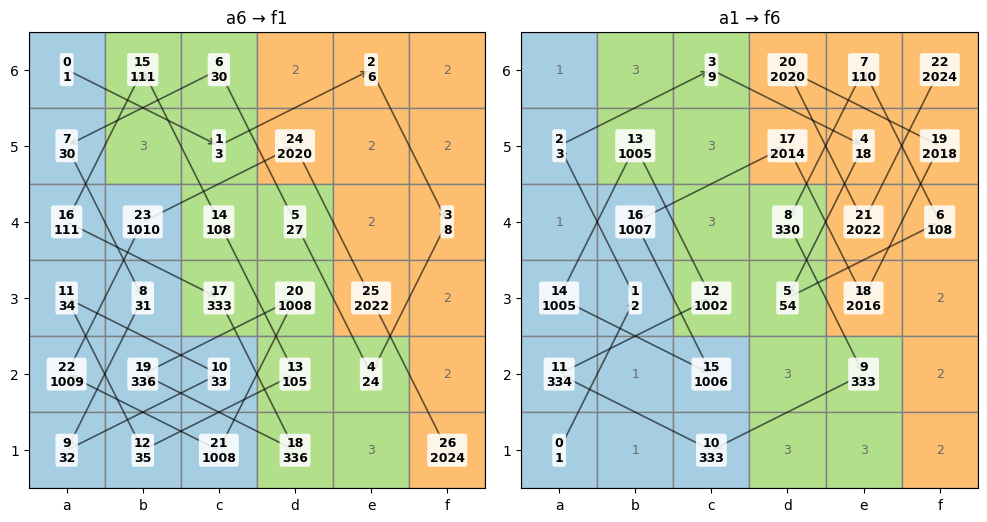

In [691]:
show_solution(solutions, a, b, c)

## Final solution

Found a solution !
Last thing to do is to convert the found solution to the puzzle's wanted format, nothing complicated.
It's the end of the puzzle. Thanks for reading me !

In [696]:
def format_entry(a, b, c, solution):
    bottom_path, top_path = solution  # first = a6->f1, second = a1->f6

    def square_name(coord):
        r, col = coord
        return "abcdef"[col] + str(6-r)

    top_squares = [square_name(coord) for coord, _ in top_path]
    bottom_squares = [square_name(coord) for coord, _ in bottom_path]

    return ",".join([str(a), str(b), str(c)] + top_squares + bottom_squares)


In [697]:
puzzle_solution = format_entry(a, b, c, solutions)
print(puzzle_solution)

1,3,2,a1,b3,a5,c6,e5,d3,f4,e6,d4,e2,c1,a2,c3,b5,a3,c2,b4,d5,e3,f5,d6,e4,f6,a6,c5,e6,f4,e2,d4,c6,a5,b3,a1,c2,a3,b1,d2,c4,b6,a4,c3,d1,b2,d3,c1,a2,b4,d5,e3,f1


# Conclusion/Takeaways

Jane Street puzzles always make us learn something. In this puzzle, we had to work out ideas to not end up trying all the possible paths. Pruning in search algorithms are a well-known method but using it wisely is complicated and most importantly specific to you problem.

This was my take on the problem and of course, there might be plenty other ways to solve this puzzle some of them quicker and some of them more beautiful than just some pruning. I am doing this as a learning process and always try to do something alone even if it's shit. Writing the thought process also helps me keep a note on why I did the things I did and this whole GitHub is mostly for me to have a written footprint of what I did.

## Takeaways

This notebook shares the thought process when I was solving this puzzle. Obviously, there have been some misteps and sometimes, the code just wasn't as optimized as it could be which led me to go back to it several times and try different methods.

For instance, these are the things I should be more careful about next time:
- Got too deep too quickly into the knights moves, should have started with the numbers
- Took the score idea too literaly and immediately tried to deal with additions and multiplications when substractions and divisions were better

These two points reflect that I was too quick and didn't take enough time to think through the problem before diving into it.

I will write a cleaner version that maybe runs faster if I ever manage to optimize my code.